# Análise exploratória Spaceship Titanic

## Importando dependências e dados

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/train.csv')

## Informações do conjunto de dados

**1 PassengerId** - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

**2 HomePlanet** - The planet the passenger departed from, typically their planet of permanent residence.

**3 CryoSleep** - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

**4 Cabin** - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

**5 Destination** - The planet the passenger will be debarking to.

**6 Age** - The age of the passenger.

**7 VIP** - Whether the passenger has paid for special VIP service during the voyage.

**8, 9, 10, 11, 12 RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

**13 Name** - The first and last names of the passenger.

**14 Transported** - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.


## Avaliação macro dos dados

In [4]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.shape

(8693, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


## Checando valores nulos

In [7]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

## Valores únicos por variável

In [8]:
valores_unicos = []
colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    print(f'{coluna}: {df[coluna].nunique()}')

PassengerId: 8693
HomePlanet: 3
CryoSleep: 2
Cabin: 6560
Destination: 3
VIP: 2
Name: 8473


## Medidas estatísticas principais do dataset

In [9]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## Avaliação de variáveis individualmente

In [20]:
df.groupby(['HomePlanet']).size()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
dtype: int64

In [21]:
df.groupby(['HomePlanet', 'Destination'])['Transported'].mean()

HomePlanet  Destination  
Earth       55 Cancri e      0.504348
            PSO J318.5-22    0.498596
            TRAPPIST-1e      0.389229
Europa      55 Cancri e      0.689616
            PSO J318.5-22    0.736842
            TRAPPIST-1e      0.634987
Mars        55 Cancri e      0.611399
            PSO J318.5-22    0.448980
            TRAPPIST-1e      0.511864
Name: Transported, dtype: float64

In [22]:
df['CryoSleep'].value_counts()

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

In [35]:
df['Destination'].value_counts()

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

<Axes: ylabel='Destination'>

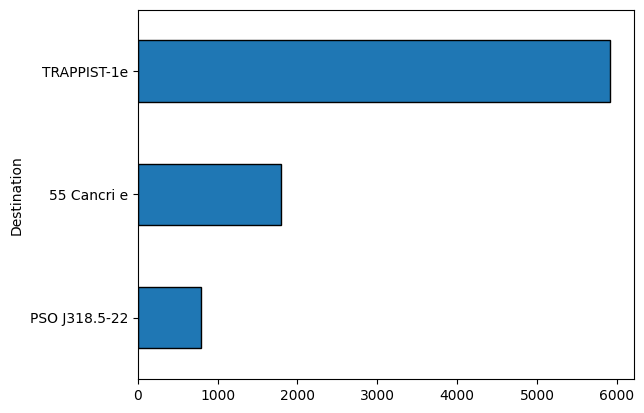

In [44]:
df['Destination'].value_counts().sort_values(ascending=True).plot(
    kind='barh', 
    edgecolor='black'
)

In [26]:
df['VIP'].value_counts()

VIP
False    8291
True      199
Name: count, dtype: int64

## Balanceamento do target

In [39]:
df.groupby(['Transported']).size()

Transported
False    4315
True     4378
dtype: int64

## Análise de relação de cada variável x variável alvo

In [50]:
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.autolayout'] = True

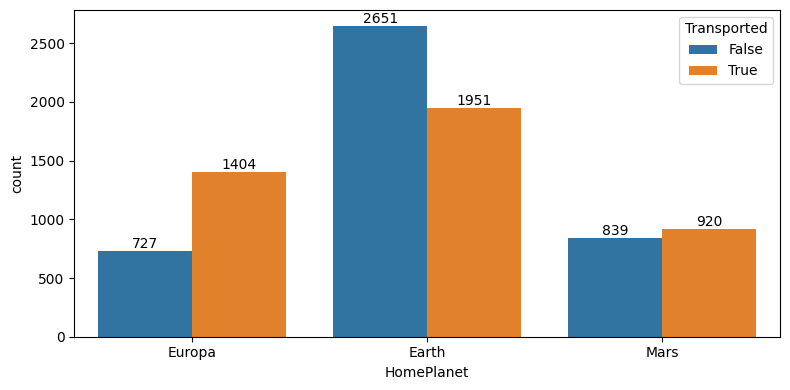

In [52]:
ax = sns.countplot(
    data=df,
    x='HomePlanet',
    hue='Transported',
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

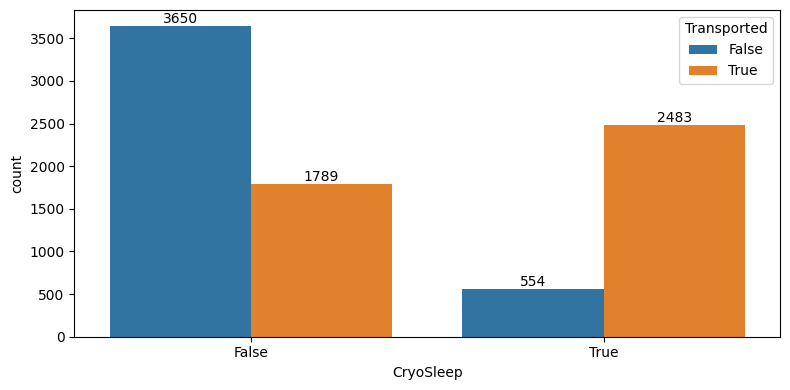

In [55]:
ax = sns.countplot(
    data=df,
    x='CryoSleep',
    hue='Transported',
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

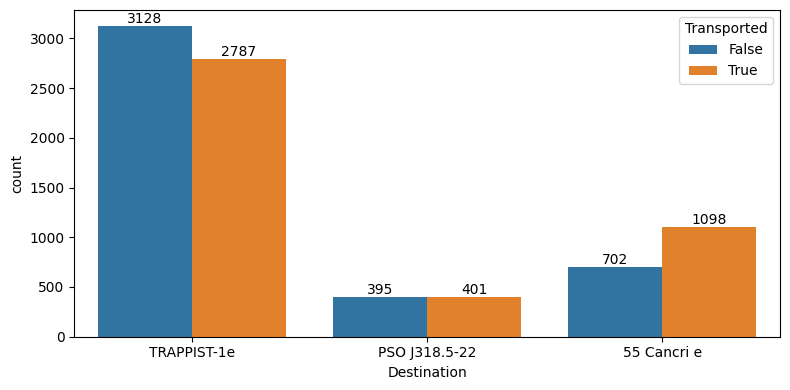

In [53]:
ax = sns.countplot(
    data=df,
    x='Destination',
    hue='Transported',
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

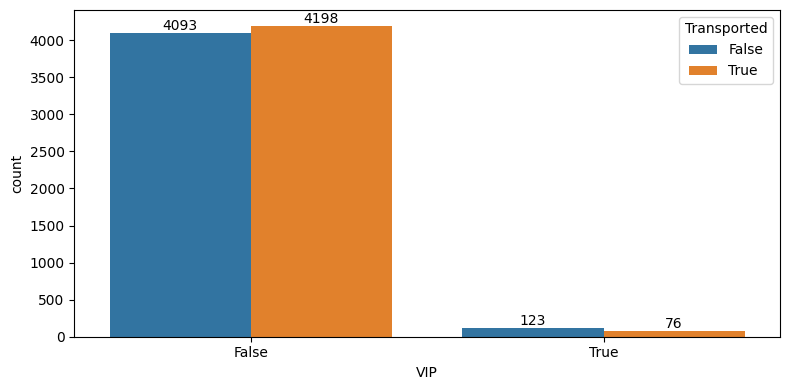

In [54]:
ax = sns.countplot(
    data=df,
    x='VIP',
    hue='Transported',
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Análise de possíveis outliers

In [56]:
variaveis_numericas = []
for i in df.columns.to_list():
    if df[i].dtype in ['int64', 'float64']:
        variaveis_numericas.append(i)

In [59]:
variaveis_numericas

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [61]:
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['figure.autolayout'] = True

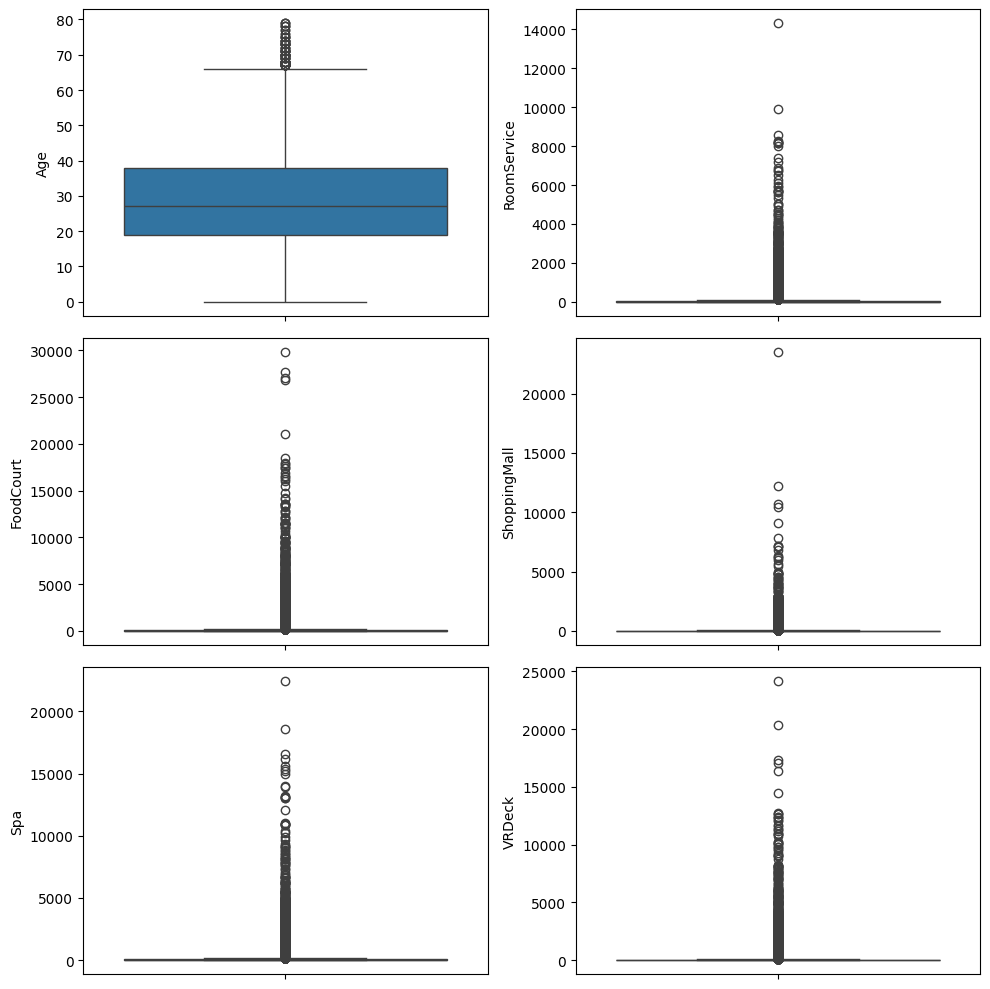

In [62]:
fig, axes = plt.subplots(3, 2)

row = 0
col = 0
for i in variaveis_numericas:
    sns.boxplot(
        data=df,
        y=i,
        ax=axes[row][col]
    )
    col += 1
    if col == 2:
        row += 1
        col = 0
plt.show()

## Análise de distribuição dos dados

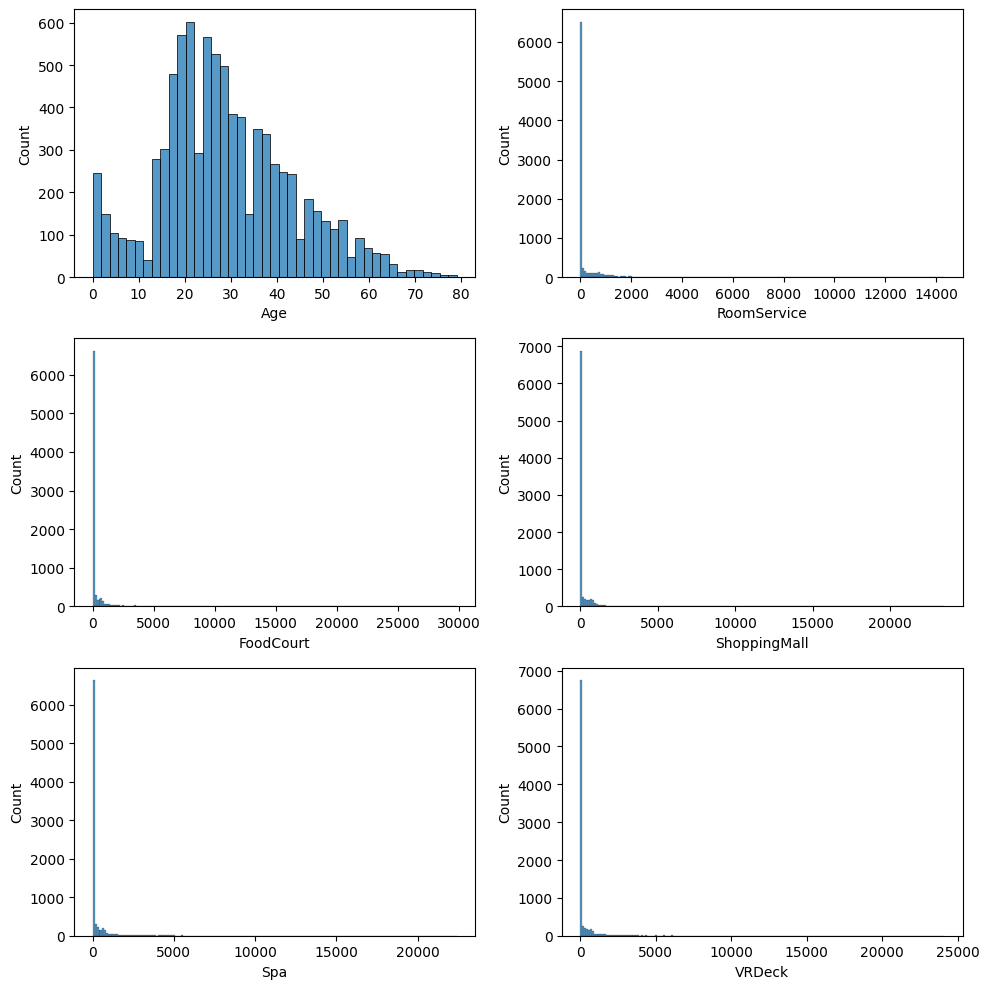

In [63]:
fig, axes = plt.subplots(3, 2)

row = 0
col = 0
for i in variaveis_numericas:
    sns.histplot(
        data=df,
        x=i,
        ax=axes[row][col]
    )
    col += 1
    if col == 2:
        row += 1
        col = 0
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

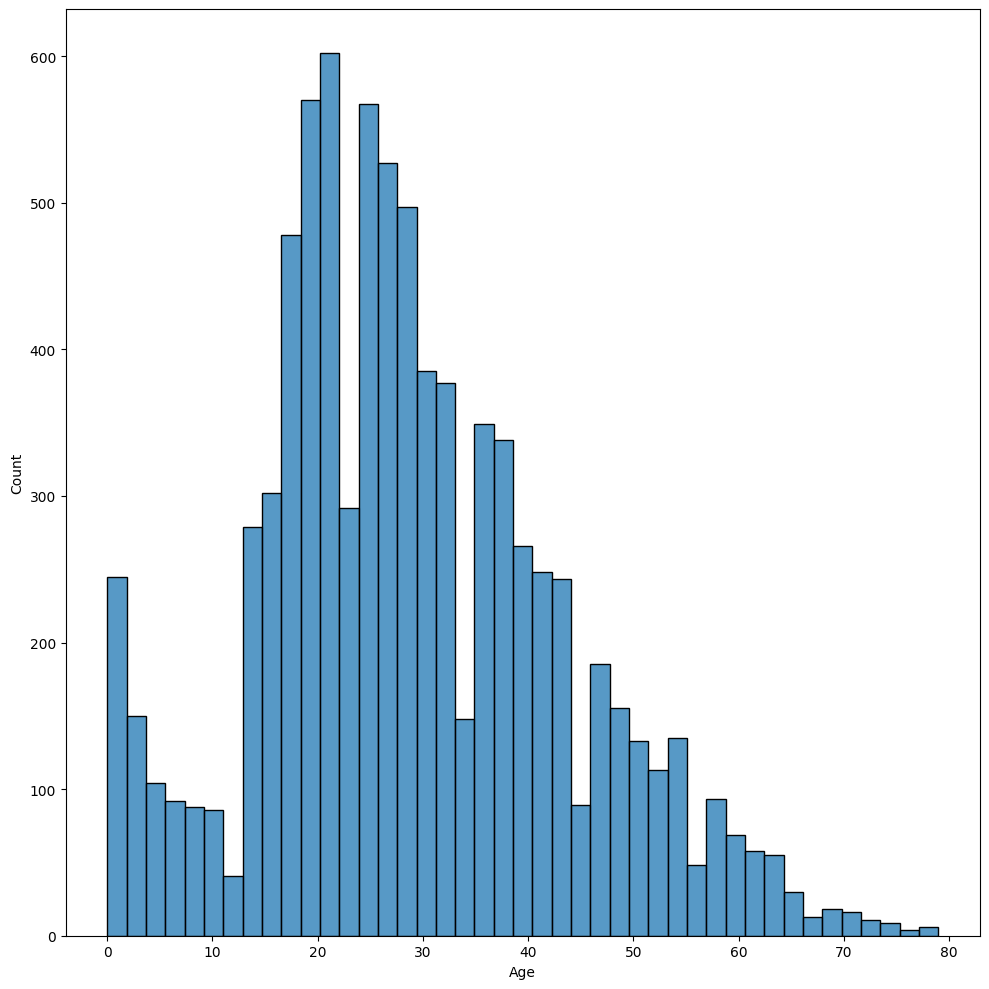

In [66]:
sns.histplot(data=df, x='Age', edgecolor='black')